# NLP-Driven RL Trading Platform - One-Click Implementation Report

这个 notebook 是项目的总控 implement 文件。你可以在下面的交互控制面板里选择或输入股票代码、日期、数据源等参数，然后按顺序运行后面的 cells，就会完成：

- 数据抓取或复用已有数据
- NLP daily sentiment 生成（Lexicon、TF-IDF Logistic、FinBERT fallback）
- 每日资金净流入/净流出 proxy 生成
- with/without NLP ablation 对比
- Sharpe Ratio、Max Drawdown、Buy-and-Hold benchmark 汇总
- RL state vector 合规性检查
- walk-forward validation 切分说明
- 自动生成一份 markdown 报告草稿

默认配置使用仓库里已经存在的样例数据，保证第一次运行比较稳。需要重新搜索股票数据时，在控制面板里勾选 `Run data ingestion`。

## Program Workflow

```mermaid
flowchart TD
    A[Custom run settings\nStock code, company name, date range, data source] --> B{Run data ingestion?}
    B -- Yes --> C[program/run_scraper.py\nFetch OHLCV + text/news/event data]
    B -- No --> D[Reuse existing CSV\noutputs/stocks/<symbol>/data/*_finance_text_*.csv]
    C --> E[Raw integrated dataset\nDaily price + event_count + keywords]
    D --> E
    E --> F[src.experiments.run_all_analysis\nGenerate analysis artifacts]
    F --> G[NLP daily sentiment\nLexicon + TF-IDF Logistic + FinBERT fallback]
    F --> H[Ablation metrics\nwith NLP vs without NLP vs buy-and-hold]
    F --> O[Daily net flow proxy\nreported net-flow or OHLCV estimate]
    E --> I[Technical indicators\nMA50, MA200, RSI, MACD]
    G --> J[RL state vector check\nprice, indicators, position, cash, sentiment_score]
    I --> J
    J --> K[Walk-forward validation setup\nchronological train/test windows]
    H --> L[Performance visualization\nSharpe, MDD, final equity]
    O --> L
    K --> M[Guideline checklist]
    L --> N[Auto report draft\noutputs/stocks/<symbol>/reports/*_report_draft.md]
    M --> N
```

Notebook execution order: first apply the custom settings, then run sections 2-8 from top to bottom.

In [11]:
from __future__ import annotations

import datetime as dt
import json
import os
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Markdown, clear_output, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".matplotlib_cache"))
sys.path.insert(0, str(PROJECT_ROOT))

from src.config.paths import legacy_data_dirs, stock_data_dir, stock_reports_dir, stock_results_dir
from src.data_ingestion.cache import build_master_csv, cache_covers_range, resolve_cached_csv
from src.data_ingestion.ingestion import IngestionConfig, run_ingestion
from src.evaluation.walk_forward import split_frame_walk_forward
from src.features.money_flow import compute_daily_net_flow
from src.features.technical_indicators import STATE_COLUMNS, add_trading_features, validate_state_columns

try:
    import ipywidgets as widgets
    WIDGETS_ERROR = None
except Exception as exc:
    widgets = None
    WIDGETS_ERROR = exc

try:
    import matplotlib.pyplot as plt
    plt.style.use("seaborn-v0_8-whitegrid")
    MATPLOTLIB_ERROR = None
except Exception as exc:
    plt = None
    MATPLOTLIB_ERROR = exc

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)


## 1. Custom Run Control Panel

先运行下一格，然后在面板里选择或输入股票、日期和数据源。改完以后点击 `Apply custom run settings`，再从第 2 节开始继续运行。

当前 scraper wrapper 主要支持中国 A 股 6 位代码，例如 `002475`、`600519`、`300750`。

In [2]:
DEFAULT_CONFIG = {
    "symbol": "002475",
    "company_name": "立讯精密",
    "start_date": "2026-04-15",
    "end_date": "2026-04-22",
    "sources": "tencent",
    "news_count": 5000,
    "run_ingestion": False,
    "reuse_existing_csv": True,
    "require_news": False,
    "episodes": 200,
    "train_days": 252,
    "test_days": 63,
}

CONFIG = DEFAULT_CONFIG.copy()
reports_dir = stock_reports_dir(CONFIG["symbol"])
reports_dir.mkdir(parents=True, exist_ok=True)
stock_alias_path = PROJECT_ROOT / "config" / "stock_aliases.json"
if stock_alias_path.exists():
    STOCK_ALIASES = json.loads(stock_alias_path.read_text(encoding="utf-8"))
else:
    STOCK_ALIASES = {}


def normalize_panel_symbol(value: str) -> str:
    text = str(value or "").strip().upper()
    digits = "".join(ch for ch in text if ch.isdigit())
    return digits[:6] if len(digits) >= 6 else text.replace(".", "_")


def company_from_existing_master(symbol: str) -> str:
    code = normalize_panel_symbol(symbol)
    search_dirs = [stock_data_dir(code), *legacy_data_dirs()]
    for directory in search_dirs:
        for path in sorted(directory.glob(f"{code}_finance_text_master.csv")):
            try:
                sample = pd.read_csv(path, usecols=lambda col: col in {"company_name"}, nrows=20)
            except Exception:
                continue
            if "company_name" not in sample.columns:
                continue
            for value in sample["company_name"].dropna().astype(str):
                value = value.strip()
                if value and value != code and not value.isdigit():
                    return value
    return ""


def typed_company_is_stale(symbol: str, typed_company: str = "") -> bool:
    code = normalize_panel_symbol(symbol)
    typed_company = str(typed_company or "").strip()
    if not typed_company:
        return False
    expected_for_symbol = preset_company_by_symbol.get(code)
    if expected_for_symbol == typed_company:
        return False
    return typed_company in preset_company_values


def resolve_company_name(symbol: str, typed_company: str = "") -> tuple[str, str]:
    code = normalize_panel_symbol(symbol)
    typed_company = str(typed_company or "").strip()
    stale_typed_company = typed_company_is_stale(code, typed_company)
    if typed_company and not stale_typed_company:
        return typed_company, "manual"
    if code in STOCK_ALIASES:
        return STOCK_ALIASES[code], "stock_aliases.json"
    existing = company_from_existing_master(code)
    if existing:
        return existing, "existing master CSV"
    return "", "missing"


def refresh_paths() -> None:
    global safe_symbol, input_csv, reports_dir, results_dir
    safe_symbol = normalize_panel_symbol(CONFIG["symbol"])
    input_csv = stock_data_dir(safe_symbol) / f"{safe_symbol}_finance_text_{CONFIG['start_date']}_{CONFIG['end_date']}.csv"
    reports_dir = stock_reports_dir(safe_symbol)
    results_dir = stock_results_dir(safe_symbol)
    input_csv.parent.mkdir(parents=True, exist_ok=True)
    reports_dir.mkdir(parents=True, exist_ok=True)
    results_dir.mkdir(parents=True, exist_ok=True)


def local_timeline_bounds(symbol: str) -> tuple[pd.Timestamp | None, pd.Timestamp | None, int]:
    master = build_master_csv(symbol)
    if master is None or master.empty or "date" not in master.columns:
        return None, None, 0
    dates = pd.to_datetime(master["date"], errors="coerce").dropna()
    if dates.empty:
        return None, None, 0
    return dates.min(), dates.max(), len(dates)


def show_active_config() -> None:
    refresh_paths()
    mode = "scrape fresh data" if CONFIG["run_ingestion"] else "reuse existing CSV"
    local_start, local_end, local_rows = local_timeline_bounds(CONFIG["symbol"])
    if input_csv.exists():
        file_status = "exists"
    elif cache_covers_range(CONFIG["symbol"], CONFIG["start_date"], CONFIG["end_date"]):
        file_status = "covered by local cache"
    else:
        file_status = "missing"
    display(Markdown(
        f"**Active run:** `{CONFIG['symbol']}` `{CONFIG.get('company_name') or ''}` "
        f"from `{CONFIG['start_date']}` to `{CONFIG['end_date']}` | sources: `{CONFIG['sources']}` | mode: **{mode}**"
    ))
    display(Markdown(f"**Expected data file:** `{input_csv.relative_to(PROJECT_ROOT)}` | status: **{file_status}**"))
    if local_start is not None and local_end is not None:
        display(Markdown(
            f"**Local cached timeline:** `{local_start.date()}` to `{local_end.date()}` | rows: `{local_rows}`"
        ))
        if not input_csv.exists() and file_status == "covered by local cache":
            display(Markdown(
                "Requested range is already covered by local market/news timeline. "
                "Section 2 will materialize the exact date-range CSV from cache without scraping new data."
            ))
    else:
        display(Markdown("**Local cached timeline:** none found for this symbol yet."))


refresh_paths()

stock_presets = {
    "002475 - 立讯精密": ("002475", "立讯精密"),
    "600519 - 贵州茅台": ("600519", "贵州茅台"),
    "300750 - 宁德时代": ("300750", "宁德时代"),
    "000002 - 万科A": ("000002", "万科A"),
    "000625 - 长安汽车": ("000625", "长安汽车"),
    "Custom manual input": (CONFIG["symbol"], CONFIG["company_name"]),
}
preset_company_values = {company for symbol, company in stock_presets.values() if company}
preset_company_by_symbol = {normalize_panel_symbol(symbol): company for symbol, company in stock_presets.values() if company}

if widgets is None:
    display(Markdown(f"ipywidgets is unavailable: `{WIDGETS_ERROR}`. Edit `CONFIG` manually in this cell, then run the notebook."))
    show_active_config()
else:
    preset_dropdown = widgets.Dropdown(
        options=list(stock_presets.keys()),
        value="002475 - 立讯精密",
        description="Preset",
        layout=widgets.Layout(width="420px"),
    )
    symbol_text = widgets.Text(value=CONFIG["symbol"], description="Symbol", layout=widgets.Layout(width="260px"))
    company_text = widgets.Text(
        value=CONFIG["company_name"],
        description="Company",
        placeholder="请输入公司中文名；未知时会先查 config/stock_aliases.json 和 master CSV",
        layout=widgets.Layout(width="420px"),
    )
    company_help = widgets.HTML(value="")
    autofill_company_button = widgets.Button(
        description="Auto-fill company",
        button_style="info",
        icon="search",
        layout=widgets.Layout(width="190px"),
    )
    start_picker = widgets.DatePicker(value=dt.date.fromisoformat(CONFIG["start_date"]), description="Start date")
    end_picker = widgets.DatePicker(value=dt.date.fromisoformat(CONFIG["end_date"]), description="End date")
    sources_text = widgets.Text(value=CONFIG["sources"], description="Sources", layout=widgets.Layout(width="360px"))
    news_count_int = widgets.IntText(value=CONFIG["news_count"], description="News cap", layout=widgets.Layout(width="220px"))
    run_ingestion_check = widgets.Checkbox(value=CONFIG["run_ingestion"], description="Run data ingestion")
    reuse_existing_check = widgets.Checkbox(value=CONFIG["reuse_existing_csv"], description="Reuse CSV if it already exists")
    require_news_check = widgets.Checkbox(value=CONFIG["require_news"], description="Require news/events")
    episodes_int = widgets.IntText(value=CONFIG["episodes"], description="Episodes", layout=widgets.Layout(width="220px"))
    train_days_int = widgets.IntText(value=CONFIG["train_days"], description="Train days", layout=widgets.Layout(width="220px"))
    test_days_int = widgets.IntText(value=CONFIG["test_days"], description="Test days", layout=widgets.Layout(width="220px"))
    apply_button = widgets.Button(
        description="Apply custom run settings",
        button_style="success",
        icon="check",
        layout=widgets.Layout(width="280px"),
    )
    status_output = widgets.Output()

    def update_company_help(message: str = "", level: str = "info") -> None:
        colors = {"info": "#1f4e79", "warn": "#9a6700", "ok": "#116329"}
        color = colors.get(level, "#1f4e79")
        company_help.value = f'<span style="color:{color}; font-weight:600;">{message}</span>' if message else ""

    def auto_fill_company(force: bool = False) -> None:
        code = normalize_panel_symbol(symbol_text.value)
        stale_preset_company = typed_company_is_stale(code, company_text.value)
        if stale_preset_company:
            company_text.value = ""
        company, source = resolve_company_name(code, company_text.value)
        should_replace = force or not company_text.value.strip() or stale_preset_company
        if company and should_replace:
            company_text.value = company
            update_company_help(f"Company auto-filled from {source}: {company}", "ok")
        elif company_text.value.strip():
            update_company_help(f"Using typed company keyword: {company_text.value.strip()}", "info")
        else:
            update_company_help(
                f"No company name found for {code}. The scraper will search by code variants only; type the Chinese company name for stronger news matching.",
                "warn",
            )

    def on_symbol_change(change):
        if change["new"] == change["old"]:
            return
        if preset_dropdown.value != "Custom manual input":
            preset_dropdown.unobserve(on_preset_change, names="value")
            preset_dropdown.value = "Custom manual input"
            preset_dropdown.observe(on_preset_change, names="value")
        auto_fill_company(force=False)

    def on_preset_change(change):
        if change["new"] == "Custom manual input":
            auto_fill_company(force=False)
            return
        symbol, company = stock_presets[change["new"]]
        symbol_text.unobserve(on_symbol_change, names="value")
        symbol_text.value = symbol
        symbol_text.observe(on_symbol_change, names="value")
        company_text.value = company
        update_company_help(f"Company selected from preset: {company}", "ok")

    def on_autofill_company(_button):
        auto_fill_company(force=True)

    def on_apply_clicked(_button):
        with status_output:
            clear_output()
            start_date = start_picker.value or dt.date.fromisoformat(DEFAULT_CONFIG["start_date"])
            end_date = end_picker.value or dt.date.fromisoformat(DEFAULT_CONFIG["end_date"])
            resolved_company, company_source = resolve_company_name(symbol_text.value, company_text.value)
            if resolved_company and not company_text.value.strip():
                company_text.value = resolved_company
            CONFIG.update(
                {
                    "symbol": normalize_panel_symbol(symbol_text.value),
                    "company_name": resolved_company,
                    "start_date": start_date.isoformat(),
                    "end_date": end_date.isoformat(),
                    "sources": sources_text.value.strip() or "tencent",
                    "news_count": int(news_count_int.value),
                    "run_ingestion": bool(run_ingestion_check.value),
                    "reuse_existing_csv": bool(reuse_existing_check.value),
                    "require_news": bool(require_news_check.value),
                    "episodes": int(episodes_int.value),
                    "train_days": int(train_days_int.value),
                    "test_days": int(test_days_int.value),
                }
            )
            if not CONFIG["symbol"]:
                raise ValueError("Symbol cannot be empty.")
            if not CONFIG["company_name"]:
                update_company_help(
                    "Company is empty: scraper will search by stock code only. Fill Chinese company name for better news matching.",
                    "warn",
                )
            else:
                update_company_help(f"Company keyword for news search: {CONFIG['company_name']} ({company_source})", "ok")
            if dt.date.fromisoformat(CONFIG["start_date"]) > dt.date.fromisoformat(CONFIG["end_date"]):
                raise ValueError("Start date cannot be after end date.")
            show_active_config()

    preset_dropdown.observe(on_preset_change, names="value")
    symbol_text.observe(on_symbol_change, names="value")
    autofill_company_button.on_click(on_autofill_company)
    apply_button.on_click(on_apply_clicked)

    controls = widgets.VBox(
        [
            widgets.HBox([preset_dropdown, symbol_text, company_text, autofill_company_button]),
            company_help,
            widgets.HBox([start_picker, end_picker, sources_text, news_count_int]),
            widgets.HBox([run_ingestion_check, reuse_existing_check, require_news_check]),
            widgets.HBox([episodes_int, train_days_int, test_days_int, apply_button]),
            status_output,
        ]
    )
    display(controls)
    with status_output:
        show_active_config()


## Customization Manual

### Panel 可以调试什么

这个 notebook 顶部的 control panel 是整个项目的运行入口。你在这里改参数，然后点击 `Apply custom run settings`，后面的数据抓取、NLP、RL、ablation 和报告生成都会按这组配置运行。

| 控件 | 作用 | 什么时候需要改 |
|---|---|---|
| `Preset` | 从常用股票里快速选择代码和公司名 | 想快速切换到已配置股票时使用 |
| `Symbol` | 股票代码，例如 `000002`、`002475` | 跑自定义股票时填写，A 股一般填 6 位代码 |
| `Company` | 公司中文名，用于新闻/公告搜索 | 新闻抓取不准或换股票时一定要改 |
| `Auto-fill company` | 按 Symbol 从 `config/stock_aliases.json` 或已有 master CSV 查公司名 | 输入不在 preset 里的股票代码后点击它 |
| `Start date` / `End date` | 样本区间 | 控制价格数据、新闻数据、训练/测试评估覆盖的时间范围 |
| `Sources` | 数据源，支持逗号分隔，例如 `tencent` 或 `tencent,eastmoney` | 某个源抓不到数据时换源或加备用源 |
| `News cap` | 最多抓取/保留的新闻文本数量 | 新闻太多导致运行慢时调小；想提高覆盖率时调大 |
| `Run data ingestion` | 是否重新抓取数据 | 新股票、新日期、新数据源时必须勾选；只复用已有 CSV 时不用勾 |
| `Reuse CSV if it already exists` | 如果目标 CSV 已存在就直接复用 | 调试模型时建议勾选，避免重复抓数据 |
| `Require news/events` | 如果没有新闻/事件就报错停止 | 需要严格验证 NLP 模块时勾选；只想先跑通价格/RL 时可以不勾 |
| `Episodes` | DQN 训练轮数 | 正式实验至少 200；快速检查 pipeline 可以先设 1 到 10 |
| `Train days` | walk-forward 每个训练窗口长度 | 想测试模型对长/短历史窗口的敏感性时调整 |
| `Test days` | walk-forward 每个测试窗口长度 | 想调整样本外验证频率时调整 |

### 推荐调试顺序

1. 先用 `Episodes = 1` 或 `10`、`Reuse CSV if it already exists = True` 跑通整条 pipeline。
2. 确认 CSV、sentiment、ablation、report 都生成后，再把 `Episodes` 改成 `200` 做正式实验。
3. 如果换了股票或日期范围，勾选 `Run data ingestion`，否则 notebook 会去找一个还不存在的 CSV。
4. 自定义股票时，如果 `Company` 没有自动出现，先点 `Auto-fill company`；如果仍然找不到，手动填公司中文名。
5. 如果 NLP 图大部分是 0，优先检查 `Company`、`Sources`、`News cap` 和 `Require news/events`。
6. 如果 DQN 长期只 Hold，可以增加 `Episodes`、扩大日期范围，或比较 `dqn_without_nlp` 和 `dqn_with_nlp` 的交易日志。

### Which mode should I use?

- If the expected CSV already exists in `outputs/stocks/<symbol>/data/`, leave `Run data ingestion` unchecked. This is the fastest mode.
- If the panel shows `covered by master cache`, the exact date-range CSV can be recreated from the stock master file without scraping again.
- If you choose a new stock or a new date range, check `Run data ingestion`. Otherwise the notebook will look for a CSV that has not been created yet.
- Keep `Reuse CSV if it already exists` checked when you do not want to scrape again for a file that already exists.
- Check `Require news/events` only when you want the run to fail if no text/news/event records are collected.

### Recommended source settings

- `tencent`: recommended default for China A-share OHLCV data.
- `eastmoney`: useful fallback for A-share data and announcements.
- `tencent,eastmoney`: tries Tencent first, then Eastmoney if needed.

### Common error: input CSV not found

If you see an error saying the expected CSV does not exist, it usually means you changed the stock/date range but did not check `Run data ingestion`. Fix it by either:

- checking `Run data ingestion`, clicking `Apply custom run settings`, then running section 2 again; or
- changing the date range back to a CSV that already exists in `outputs/stocks/<symbol>/data/`.

For example, if the panel shows `outputs/stocks/<symbol>/data/002475_finance_text_2024-01-01_2026-04-22.csv` but that file is not in `outputs/stocks/<symbol>/data/`, the notebook cannot reuse it. You must scrape it first.


## 2. Data Ingestion and Analysis Runner

这一格会根据配置决定是否重新抓取数据。随后统一调用项目已有的 `src.experiments.run_all_analysis` 生成 sentiment 和 ablation 输出。

In [3]:
def run_command(cmd: list[str]) -> None:
    print("$", " ".join(str(part) for part in cmd))
    completed = subprocess.run(cmd, cwd=str(PROJECT_ROOT), text=True, capture_output=True)
    if completed.stdout:
        print(completed.stdout)
    if completed.stderr:
        print(completed.stderr)
    completed.check_returncode()


if CONFIG["run_ingestion"]:
    input_csv = run_ingestion(
        IngestionConfig(
            symbol=CONFIG["symbol"],
            company_name=CONFIG.get("company_name", ""),
            start_date=CONFIG["start_date"],
            end_date=CONFIG["end_date"],
            sources=CONFIG["sources"],
            news_count=int(CONFIG["news_count"]),
            reuse_existing_csv=bool(CONFIG["reuse_existing_csv"]),
            require_news=bool(CONFIG["require_news"]),
            output_csv=input_csv,
        )
    )
    print(f"Ingestion/cache resolved CSV: {input_csv.relative_to(PROJECT_ROOT)}")
else:
    cached = resolve_cached_csv(CONFIG["symbol"], CONFIG["start_date"], CONFIG["end_date"], output_csv=input_csv)
    if cached is not None:
        input_csv = cached.path
        print(f"Using cached CSV via {cached.source}: {input_csv.relative_to(PROJECT_ROOT)}")
    else:
        print("CONFIG['run_ingestion'] is False; using the configured existing CSV.")

if not input_csv.exists():
    existing_examples = sorted(stock_data_dir(safe_symbol).glob(f"{safe_symbol}_finance_text*.csv"))
    examples_text = "\n".join(f"- {path.relative_to(PROJECT_ROOT)}" for path in existing_examples[:8])
    raise FileNotFoundError(
        "Expected CSV was not found and no cached master covers the requested range.\n"
        f"Missing file: {input_csv.relative_to(PROJECT_ROOT)}\n\n"
        "Most likely cause: you selected a new stock/date range but left `Run data ingestion` unchecked.\n"
        "Fix option 1: go back to the control panel, check `Run data ingestion`, click `Apply custom run settings`, then rerun this cell.\n"
        "Fix option 2: choose a stock/date range that already has a CSV or master timeline in `outputs/stocks/<symbol>/data/`.\n\n"
        f"Existing CSV examples for {safe_symbol}:\n{examples_text or '- none found'}"
    )

print(f"Ready for analysis: {input_csv.relative_to(PROJECT_ROOT)}")


Using cached CSV via exact_csv: outputs/stocks/002475/data/002475_finance_text_2026-04-15_2026-04-22.csv
Ready for analysis: outputs/stocks/002475/data/002475_finance_text_2026-04-15_2026-04-22.csv


## 3. Load Outputs

读取原始行情文本数据、daily sentiment、ablation metrics 和 summary JSON。

In [4]:
# Compatibility guard for notebooks opened before the output layout migration.
if "CONFIG" not in globals():
    raise RuntimeError("Run the control panel/configuration cells first, then rerun section 2.")
if "input_csv" not in globals():
    refresh_paths()

input_csv = Path(input_csv)
if "result" in input_csv.parts or ("data" in input_csv.parts and "integrated" in input_csv.parts):
    input_csv = stock_data_dir(CONFIG["symbol"]) / input_csv.name

if not input_csv.exists():
    cached = resolve_cached_csv(CONFIG["symbol"], CONFIG["start_date"], CONFIG["end_date"], output_csv=input_csv)
    if cached is not None:
        input_csv = cached.path
        print(f"Materialized requested range from cache: {input_csv.relative_to(PROJECT_ROOT)}")

if not input_csv.exists():
    raise FileNotFoundError(
        "The integrated CSV does not exist yet. Run section 2 first, or enable `Run data ingestion` in the panel.\n"
        f"Expected: {input_csv.relative_to(PROJECT_ROOT)}"
    )


def refresh_analysis_paths() -> None:
    global stem, summary_path, sentiment_path, ablation_path, signal_diagnostics_path, drawdown_curves_path
    stem = input_csv.stem
    summary_path = reports_dir / f"{stem}_analysis_summary.json"
    standard_sentiment_path = reports_dir / f"{stem}_daily_sentiment.csv"
    proxy_sentiment_path = reports_dir / f"{stem}_daily_sentiment_proxy.csv"
    sentiment_path = standard_sentiment_path if standard_sentiment_path.exists() else proxy_sentiment_path
    ablation_path = reports_dir / f"{stem}_ablation_metrics.csv"
    signal_diagnostics_path = reports_dir / f"{stem}_signal_diagnostics.csv"
    drawdown_curves_path = stock_results_dir(CONFIG["symbol"]) / "drawdown_curves.csv"


def run_notebook_command(cmd: list[str]) -> None:
    if "run_command" in globals():
        run_command(cmd)
        return
    print("$", " ".join(str(part) for part in cmd))
    completed = subprocess.run(cmd, cwd=str(PROJECT_ROOT), text=True, capture_output=True)
    if completed.stdout:
        print(completed.stdout)
    if completed.stderr:
        print(completed.stderr)
    completed.check_returncode()


def missing_analysis_artifacts() -> list[str]:
    missing = []
    if not summary_path.exists():
        missing.append(str(summary_path.relative_to(PROJECT_ROOT)))
    if not sentiment_path.exists():
        missing.append(str(sentiment_path.relative_to(PROJECT_ROOT)))
    if not ablation_path.exists():
        missing.append(str(ablation_path.relative_to(PROJECT_ROOT)))
    return missing


refresh_analysis_paths()
missing = missing_analysis_artifacts()
if missing:
    print("Missing analysis artifacts; generating them now:")
    for item in missing:
        print(f"- {item}")
    run_notebook_command(
        [
            sys.executable,
            "-m",
            "src.experiments.run_all_analysis",
            "--input-csv",
            str(input_csv),
            "--output-dir",
            str(reports_dir),
            "--episodes",
            str(CONFIG["episodes"]),
        ]
    )
    refresh_analysis_paths()
    missing = missing_analysis_artifacts()
    if missing:
        raise FileNotFoundError(
            "Analysis finished but required artifacts are still missing:\n"
            + "\n".join(f"- {item}" for item in missing)
        )

data = pd.read_csv(input_csv)
data["date"] = pd.to_datetime(data["date"])
data = data.sort_values("date").reset_index(drop=True)
data["close"] = pd.to_numeric(data["close"], errors="coerce")
data["event_count"] = pd.to_numeric(data.get("event_count", 0), errors="coerce").fillna(0)

daily_sentiment = pd.read_csv(sentiment_path)
daily_sentiment["date"] = pd.to_datetime(daily_sentiment["date"])
if "sentiment_score_proxy" not in daily_sentiment.columns:
    score_col = "daily_sentiment_score" if "daily_sentiment_score" in daily_sentiment.columns else "sentiment_score"
    daily_sentiment["sentiment_score_proxy"] = daily_sentiment[score_col]
ablation = pd.read_csv(ablation_path)
signal_diagnostics_table = pd.read_csv(signal_diagnostics_path) if signal_diagnostics_path.exists() else pd.DataFrame()
drawdown_curves = pd.read_csv(drawdown_curves_path) if drawdown_curves_path.exists() else pd.DataFrame()
money_flow = compute_daily_net_flow(data)
money_flow_path = reports_dir / f"{stem}_daily_net_flow.csv"
money_flow.to_csv(money_flow_path, index=False, encoding="utf-8-sig")
summary = json.loads(summary_path.read_text(encoding="utf-8"))

display(data.head())
display(money_flow.head())
display(ablation)
if not signal_diagnostics_table.empty:
    display(signal_diagnostics_table)
display(Markdown(f"Rows: **{summary['rows']}** | Event coverage: **{summary['event_coverage_ratio']:.1%}** | Total events: **{summary['total_events']}**"))


,date,symbol,open,high,low,close,adjclose,volume,dividend,split,data_source,company_name,exchange,currency,instrument_type,market_cap_latest,trailing_pe_latest,forward_pe_latest,fifty_two_week_high_latest,fifty_two_week_low_latest,event_count,event_titles,event_summaries,event_publishers,event_links,event_source_types,external_event_count,generated_event_count,has_external_text,keywords,amount,amplitude_pct,change_pct,change,turnover_pct
0,2026-04-15,002475.SZ,59.00,60.98,58.45,58.78,58.78,1980038.0,NaN,NaN,tencent,立讯精密,SZSE,CNY,EQUITY,NaN,NaN,NaN,NaN,NaN,279,立讯精密拟每10股派发现金股利1.4元 || 立讯精密预计Q1归母净利润同比增长20%至22...,4月14日，立讯精密（002475）发布公告，公司拟向全体股东每10股派发现金股利1.4元（...,21世纪经济报道 || 上海证券报 || 上海证券报·中国证券网 || 上游新闻 || 东方...,http://finance.eastmoney.com/a/202604153705530...,external,279.0,0.0,1.0,etf; 亿元; 立讯精密; 创业板; 万亿元; 易方达; 万亿; 截至; 较上一日此时放量...,NaN,NaN,NaN,NaN,NaN
1,2026-04-16,002475.SZ,58.76,60.65,58.00,60.45,60.45,1996422.0,NaN,NaN,tencent,立讯精密,SZSE,CNY,EQUITY,NaN,NaN,NaN,NaN,NaN,247,电子行业4月16日资金流向日报 || 68股特大单净流入资金超2亿元 || 从立讯精密到蓝思...,（数据宝） 电子行业资金流入榜 代码 简称 今日涨跌幅（%） 今日换手率（%） 主力资金流量...,21世纪经济报道 || e公司 || 上海证券报 || 上海证券报·中国证券网 || 上游新...,http://finance.eastmoney.com/a/202604163707530...,external,247.0,0.0,1.0,etf; 亿元; 创业板; 年新高; 万亿元; 创业板指涨超; 创业板指涨; 创业板人工智能...,NaN,NaN,NaN,NaN,NaN
2,2026-04-17,002475.SZ,59.85,60.88,59.25,59.75,59.75,1343424.0,NaN,NaN,tencent,立讯精密,SZSE,CNY,EQUITY,NaN,NaN,NaN,NaN,NaN,267,电子行业资金流入榜：胜宏科技、三安光电等净流入资金居前 || 共封装光学(CPO)概念上涨3...,300303 聚飞光电 5.69 17.25 21026.28 601231 环旭电子 5....,21世纪经济报道 || 上海证券报 || 上海证券报·中国证券网 || 上游新闻 || 上观...,http://finance.eastmoney.com/a/202604173709027...,external,267.0,0.0,1.0,etf; 股王; 亿元; 股新; cpo; 创业板; 截至; 创业板指涨; 万亿元; 年新高...,NaN,NaN,NaN,NaN,NaN
3,2026-04-18,002475.SZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,立讯精密,SZSE,CNY,EQUITY,NaN,NaN,NaN,NaN,NaN,35,睿远成长价值净值创新高！傅鹏博一季度加大布局这些板块 || A股主要股指走势分化 资金持续抱...,截至一季度末，该基金前十大重仓股分别为宁德时代、东山精密、新易盛、中际旭创、胜宏科技、迈为股...,21世纪经济报道 || 上海证券报 || 上游新闻 || 中国基金报 || 中国经营报 ||...,http://finance.eastmoney.com/a/202604183709724...,external,35.0,0.0,1.0,etf; 亿元; 创业板; 股王; 截至; 七姐妹; 年新高; 含税; 创业板指刷新近; 近...,NaN,NaN,NaN,NaN,NaN
4,2026-04-19,002475.SZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,立讯精密,SZSE,CNY,EQUITY,NaN,NaN,NaN,NaN,NaN,51,深度覆盖荣耀机器人核心供应链，电子50ETF华安(515320)4月以来大涨16.41% |...,据媒体披露，立讯精密作为国内消费电子组装龙头，长期负责多家机器人与手机厂商相关整机组装。而蓝...,21世纪经济报道 || 上海证券报 || 上海证券报·中国证券网 || 东方财富Choice...,http://stock.eastmoney.com/a/20260419371000891...,external,51.0,0.0,1.0,亿元; etf; 股王; 东方证券; ipo; 日开市起停牌; 蓝思科技; 公司正在筹划通过...,NaN,NaN,NaN,NaN,NaN


,date,net_flow,net_flow_cny_million,money_flow_method,traded_value,net_flow_direction
0,2026-04-15,-0.0,-0.0,ohlcv_amount_proxy,0.0,flat
1,2026-04-16,0.0,0.0,ohlcv_amount_proxy,0.0,flat
2,2026-04-17,-0.0,-0.0,ohlcv_amount_proxy,0.0,flat
3,2026-04-18,0.0,0.0,ohlcv_amount_proxy,0.0,flat
4,2026-04-19,0.0,0.0,ohlcv_amount_proxy,0.0,flat


,experiment,seed_count,final_equity,final_equity_std,final_portfolio_value,final_portfolio_value_std,cumulative_return,cumulative_return_std,annualized_return,annualized_return_std,annualized_volatility,annualized_volatility_std,sharpe_ratio,sharpe_ratio_std,sortino_ratio,sortino_ratio_std,calmar_ratio,calmar_ratio_std,max_drawdown,max_drawdown_std,win_rate,win_rate_std,number_of_trades,number_of_trades_std,exposure_ratio,exposure_ratio_std,avg_reward,avg_reward_std,profit_factor,profit_factor_std,value_at_risk_95,value_at_risk_95_std,avg_daily_return,avg_daily_return_std,best_day_return,best_day_return_std,worst_day_return,worst_day_return_std,trade_frequency,trade_frequency_std
0,buy_and_hold,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,dqn_without_nlp,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,dqn_with_nlp,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,metric,value,description,warning_level
0,market_rows,6.0,Number of trading rows used.,info
1,close_cumulative_return,0.1573664511738686,Raw close-price return over the sample.,info
2,duplicate_dates,0,Trading rows sharing the same date.,ok
3,sentiment_coverage,0.8333333333333334,Share of trading days with at least one aligne...,ok
4,sentiment_news_count_total,1870.0,Total aligned news items used for daily sentim...,info
5,average_sentiment,0.23523577056378084,Average daily sentiment score after alignment.,info
6,sentiment_next_day_return_corr,0.49658430250866387,Correlation between aligned sentiment and next...,info
7,sentiment_method,logistic,Main sentiment generation method over the sample.,info
8,news_alignment_rule,next_trading_day_no_intraday_timestamp,Rule used to convert news timestamps/dates int...,info
9,average_net_flow,0.0,Average reported or estimated daily net flow.,info


Rows: **6** | Event coverage: **100.0%** | Total events: **2086**

## 4. Guideline Compliance: RL State Vector

Project guideline 要求 state 至少包含 `[price, MA50, MA200, RSI, MACD, position, cash, sentiment_score]`。这里直接用项目里的 feature builder 检查。

In [5]:
daily_sentiment_for_features = daily_sentiment.copy()
if "daily_sentiment_score" not in daily_sentiment_for_features.columns:
    daily_sentiment_for_features["daily_sentiment_score"] = daily_sentiment_for_features["sentiment_score_proxy"]
features = add_trading_features(data, daily_sentiment_for_features)
state_compliance = validate_state_columns(features)
state_preview = features[["date"] + STATE_COLUMNS].head(10)

display(Markdown("**State columns used by the RL environment:** `" + "`, `".join(STATE_COLUMNS) + "`"))
display(state_preview)
display(state_compliance)
display(Markdown("Guideline check passed: sentiment score is included in the RL state vector."))

**State columns used by the RL environment:** `price`, `MA50`, `MA200`, `RSI`, `MACD`, `position`, `cash`, `sentiment_score`

,date,price,MA50,MA200,RSI,MACD,position,cash,sentiment_score


,state_column,present,missing_values,shifted_correctly,leakage_prone,sentiment_column
0,price,True,0,True,False,False
1,MA50,True,0,True,False,False
2,MA200,True,0,True,False,False
3,RSI,True,0,True,False,False
4,MACD,True,0,True,False,False
5,position,True,0,True,False,False
6,cash,True,0,True,False,False
7,sentiment_score,True,0,True,False,True


Guideline check passed: sentiment score is included in the RL state vector.

## 5. Walk-Forward Validation Setup

这里展示 chronological train/test windows，说明实验没有使用未来数据。短日期样例可能没有足够长的窗口，这是正常现象；换成长时间段后会自动出现 splits。

In [6]:
splits = split_frame_walk_forward(
    features,
    CONFIG["start_date"],
    CONFIG["end_date"],
    train_days=CONFIG["train_days"],
    test_days=CONFIG["test_days"],
)

split_rows = []
for index, (train, test) in enumerate(splits, start=1):
    split_rows.append(
        {
            "split": index,
            "train_start": train["date"].min() if len(train) else pd.NaT,
            "train_end": train["date"].max() if len(train) else pd.NaT,
            "train_rows": len(train),
            "test_start": test["date"].min() if len(test) else pd.NaT,
            "test_end": test["date"].max() if len(test) else pd.NaT,
            "test_rows": len(test),
        }
    )

walk_forward_table = pd.DataFrame(split_rows)
display(walk_forward_table if not walk_forward_table.empty else Markdown("No complete walk-forward windows for this short sample range."))

No complete walk-forward windows for this short sample range.

## 6. Visual Results

图表对应报告里的 market data、NLP signal 和 ablation results。

## How to Read the Main Figures

### Close price

第一张图是所选股票在样本区间内的收盘价走势。它回答的是：这段时间股票本身处在上涨、下跌还是震荡环境。后面的策略表现需要和这张图一起看，因为如果市场单边下跌，`buy_and_hold` 很容易亏损，而 RL 策略可能会选择少交易或空仓来保护现金。

### Daily net inflow / outflow

第二张图是每日资金净流入/净流出。绿色或正值表示估算的买入压力更强，红色或负值表示估算的卖出压力更强。若数据源提供真实净流入字段，程序会直接使用；如果没有，就用 OHLCV 和成交额构造 proxy：收盘价越接近当日高点，视为买方更强；越接近低点，视为卖方更强，再乘以成交额。它不是交易所官方主力资金流，而是帮助我们补充观察市场情绪/资金压力的估算指标。

### Daily sentiment score

第三张图是每天的新闻情绪分数。每条新闻会先被 NLP 模型转成数值：positive = `1`，neutral = `0`，negative = `-1`，然后按日期取平均。柱子越高，说明当天新闻整体越正面；柱子越低，说明当天新闻整体越负面；接近 0 说明新闻偏中性、正负抵消，或者当天新闻覆盖较少。这里的信号会被合并进 RL state vector 的 `sentiment_score`。

### Ablation metrics

后两张图是 ablation 指标。Ablation 是为了证明 NLP 信号有没有贡献。这里比较三组实验：`buy_and_hold`、`dqn_without_nlp`、`dqn_with_nlp`。

- `final_equity` / `final_portfolio_value`: 最终账户价值，越高越好。
- `cumulative_return`: 累计收益率，越高越好。
- `sharpe_ratio`: 风险调整收益，通常越高越好。
- `max_drawdown`: 最大回撤，通常越接近 0 越好；负得越多代表历史最大亏损越深。
- `win_rate`: 有交易时的盈利交易占比。
- `number_of_trades`: 策略实际交易次数。

原来的 ablation 图看起来像“只生成了一类柱子”，主要是因为 `final_equity` 是资金金额，可能是 `50000` 到 `100000` 级别，而 `sharpe_ratio`、`max_drawdown` 是比例或小数，通常在 `-2` 到 `2` 或 `-1` 到 `0` 附近。它们放在同一个 y 轴上会被资金金额压扁，所以现在把资金指标和比例/风险指标分开画。


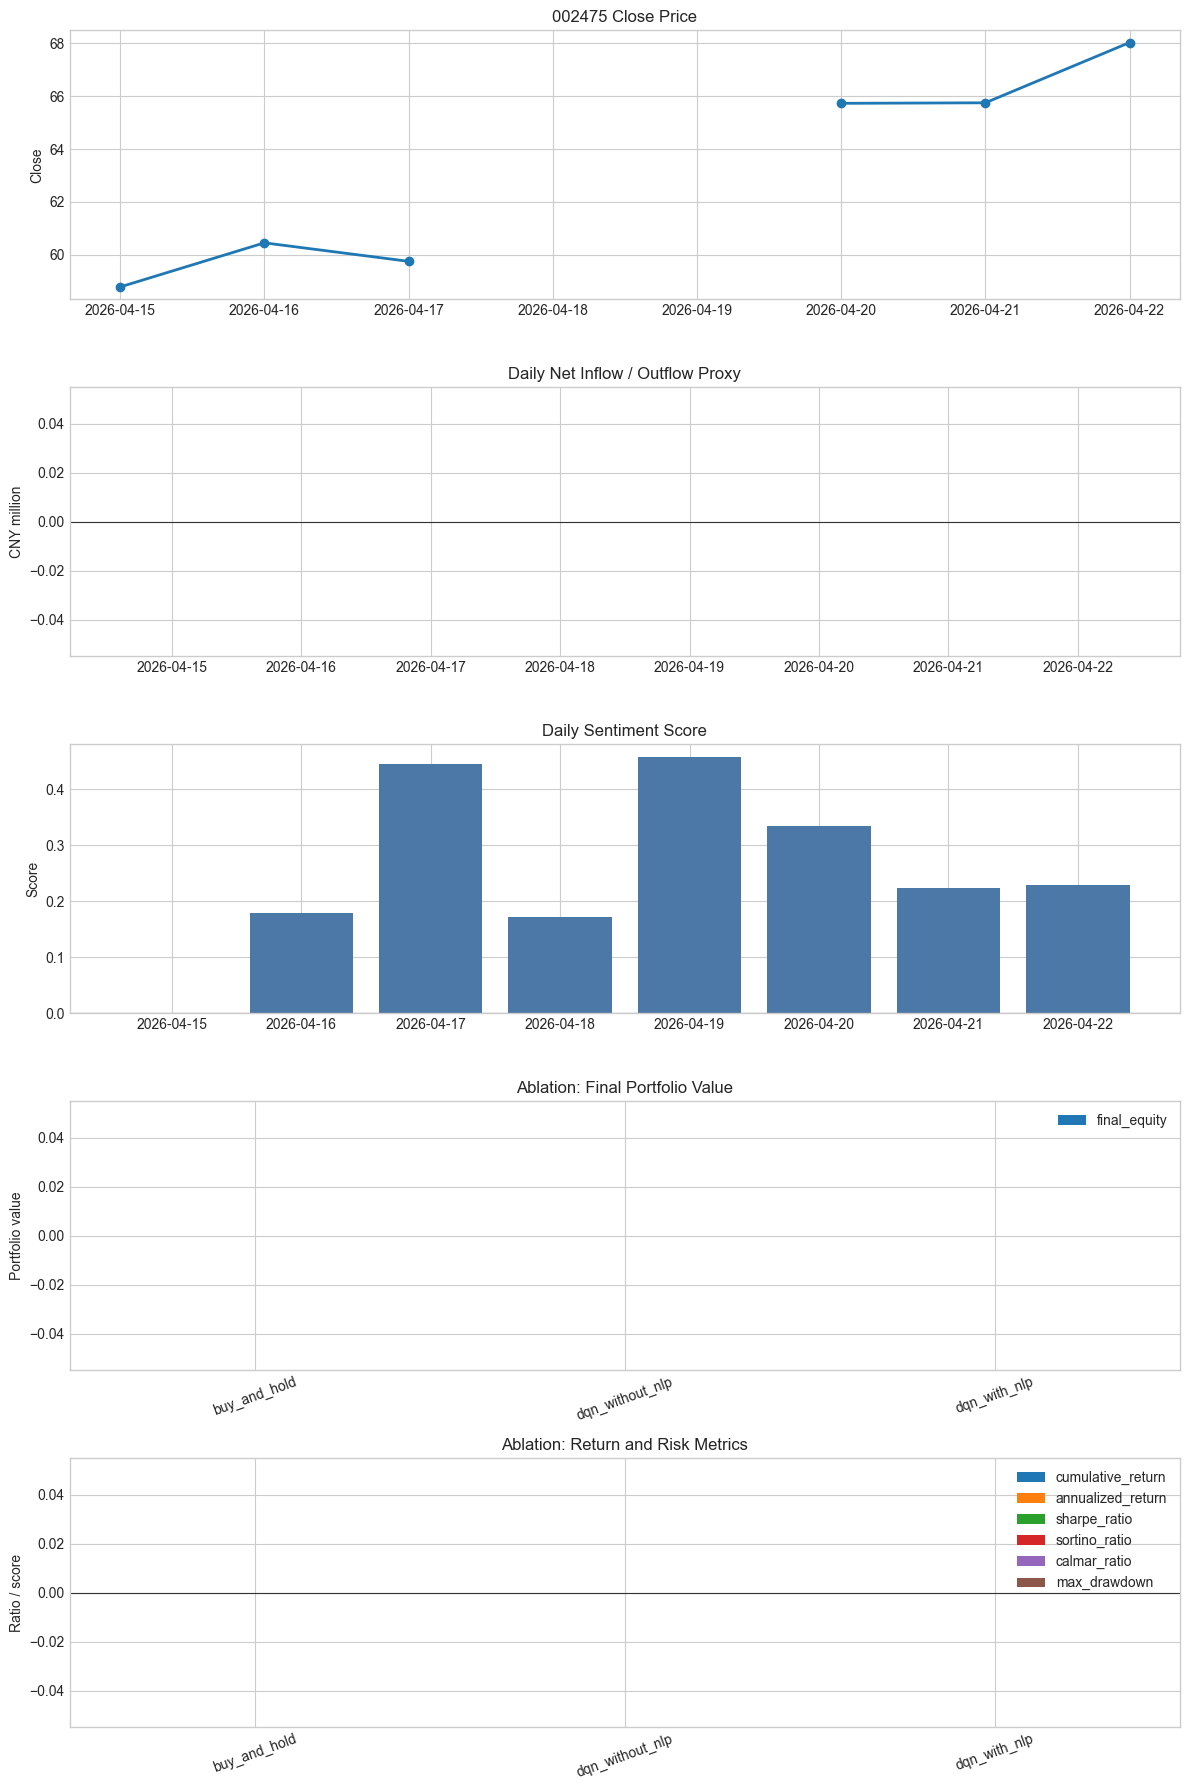

In [7]:
metric_cols = [
    "final_equity",
    "cumulative_return",
    "annualized_return",
    "annualized_volatility",
    "sharpe_ratio",
    "sortino_ratio",
    "calmar_ratio",
    "max_drawdown",
    "value_at_risk_95",
    "win_rate",
    "number_of_trades",
    "exposure_ratio",
    "profit_factor",
]
metric_cols = [col for col in metric_cols if col in ablation.columns]
metric_view = ablation.set_index("experiment")[metric_cols]

sentiment_plot_col = "sentiment_score_proxy"
if "daily_sentiment_score" in daily_sentiment.columns:
    sentiment_plot_col = "daily_sentiment_score"
elif "sentiment_score" in daily_sentiment.columns:
    sentiment_plot_col = "sentiment_score"


def show_result_tables(message=None) -> None:
    if message:
        display(Markdown(message))
    display(data[["date", "close", "event_count"]])
    display(money_flow[["date", "net_flow_cny_million", "money_flow_method", "net_flow_direction"]])
    display(daily_sentiment[["date", sentiment_plot_col]])
    display(metric_view)
    if not signal_diagnostics_table.empty:
        display(signal_diagnostics_table)


if plt is None:
    display(Markdown(f"Matplotlib is unavailable in this kernel, so tables are shown instead. Error: `{MATPLOTLIB_ERROR}`"))
    show_result_tables()
else:
    try:
        fig, axes = plt.subplots(5, 1, figsize=(12, 18), sharex=False)

        axes[0].plot(data["date"], data["close"], marker="o", linewidth=2)
        axes[0].set_title(f"{CONFIG['symbol']} Close Price")
        axes[0].set_ylabel("Close")

        flow_values = money_flow["net_flow_cny_million"]
        flow_colors = ["#16a34a" if value >= 0 else "#dc2626" for value in flow_values]
        axes[1].bar(money_flow["date"], flow_values, color=flow_colors)
        axes[1].axhline(0, color="#333333", linewidth=0.8)
        axes[1].set_title("Daily Net Inflow / Outflow Proxy")
        axes[1].set_ylabel("CNY million")

        axes[2].bar(daily_sentiment["date"], daily_sentiment[sentiment_plot_col], color="#4c78a8")
        axes[2].axhline(0, color="#333333", linewidth=0.8)
        axes[2].set_title("Daily Sentiment Score")
        axes[2].set_ylabel("Score")

        metric_view[["final_equity"]].plot(kind="bar", ax=axes[3], color=["#1f77b4"])
        axes[3].set_title("Ablation: Final Portfolio Value")
        axes[3].set_xlabel("")
        axes[3].set_ylabel("Portfolio value")
        axes[3].tick_params(axis="x", rotation=20)

        ratio_cols = [col for col in ["cumulative_return", "annualized_return", "sharpe_ratio", "sortino_ratio", "calmar_ratio", "max_drawdown"] if col in metric_view.columns]
        metric_view[ratio_cols].plot(kind="bar", ax=axes[4])
        axes[4].axhline(0, color="#333333", linewidth=0.8)
        axes[4].set_title("Ablation: Return and Risk Metrics")
        axes[4].set_xlabel("")
        axes[4].set_ylabel("Ratio / score")
        axes[4].tick_params(axis="x", rotation=20)

        plt.tight_layout()
        plt.show()
    except Exception as exc:
        show_result_tables(f"Plot rendering failed, so tables are shown instead. Error: `{exc}`")


## Additional Project-Level Comparison Visuals

这些图用于展示策略风险收益、回撤路径、交易活跃度和 NLP/资金流信号诊断，比单独看 final equity 更完整。


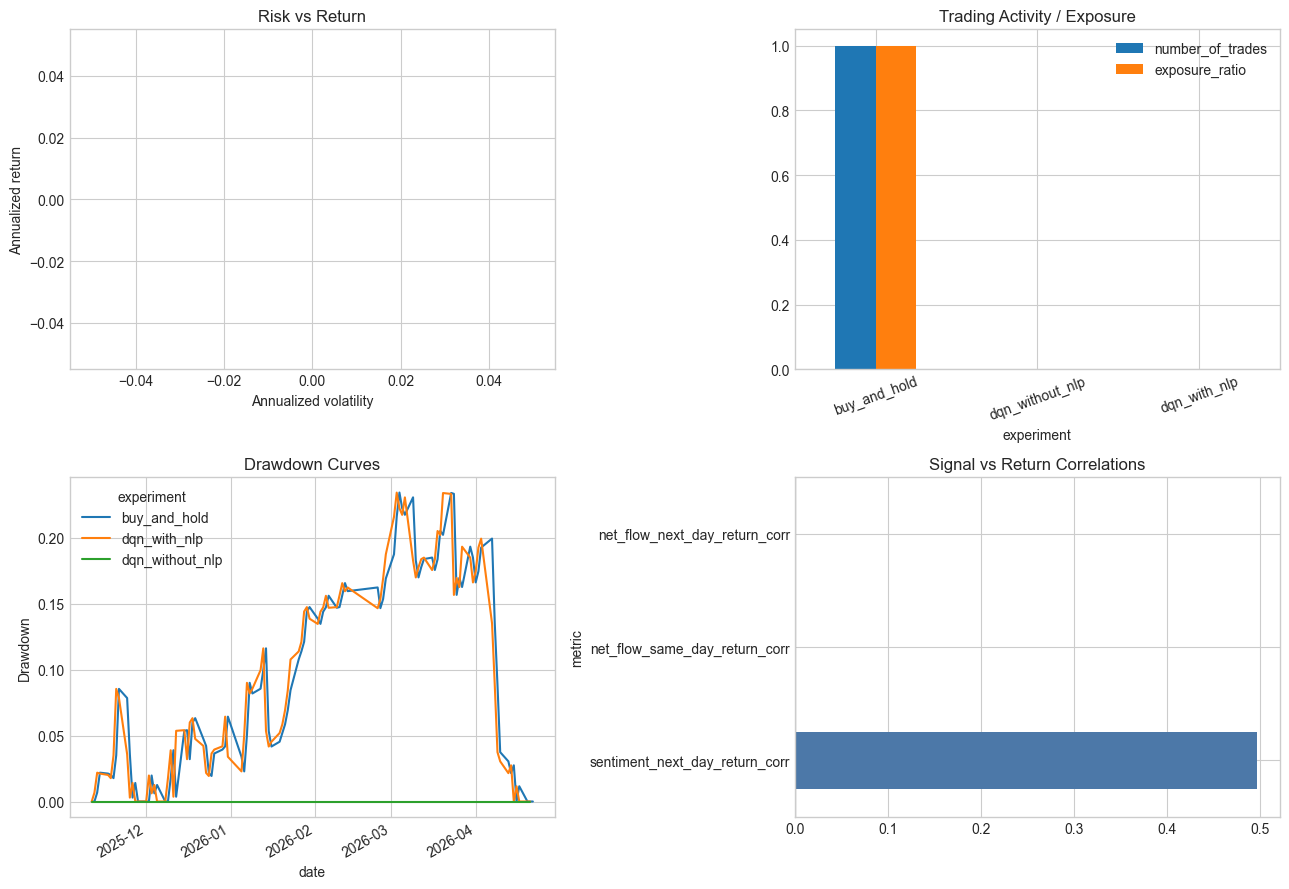

In [8]:
if plt is None:
    display(metric_view)
else:
    try:
        fig, axes = plt.subplots(2, 2, figsize=(13, 9))

        if {"annualized_volatility", "annualized_return"}.issubset(ablation.columns):
            for _, row in ablation.iterrows():
                axes[0, 0].scatter(row["annualized_volatility"], row["annualized_return"], s=90)
                axes[0, 0].annotate(row["experiment"], (row["annualized_volatility"], row["annualized_return"]))
            axes[0, 0].set_title("Risk vs Return")
            axes[0, 0].set_xlabel("Annualized volatility")
            axes[0, 0].set_ylabel("Annualized return")

        trade_cols = [col for col in ["number_of_trades", "trade_frequency", "exposure_ratio"] if col in metric_view.columns]
        if trade_cols:
            metric_view[trade_cols].plot(kind="bar", ax=axes[0, 1])
            axes[0, 1].set_title("Trading Activity / Exposure")
            axes[0, 1].tick_params(axis="x", rotation=20)

        if not drawdown_curves.empty:
            drawdown_curves["date"] = pd.to_datetime(drawdown_curves["date"])
            dd = drawdown_curves.pivot_table(index="date", columns="experiment", values="drawdown", aggfunc="last")
            dd.plot(ax=axes[1, 0])
            axes[1, 0].set_title("Drawdown Curves")
            axes[1, 0].set_ylabel("Drawdown")

        if not signal_diagnostics_table.empty:
            corr = signal_diagnostics_table[signal_diagnostics_table["metric"].str.contains("corr", case=False, na=False)].copy()
            if not corr.empty:
                corr["value"] = pd.to_numeric(corr["value"], errors="coerce")
                corr.set_index("metric")["value"].plot(kind="barh", ax=axes[1, 1], color="#4c78a8")
                axes[1, 1].axvline(0, color="#333333", linewidth=0.8)
                axes[1, 1].set_title("Signal vs Return Correlations")

        plt.tight_layout()
        plt.show()
    except Exception as exc:
        display(Markdown(f"Additional comparison plots failed, showing tables instead. Error: `{exc}`"))
        display(metric_view)
        if not signal_diagnostics_table.empty:
            display(signal_diagnostics_table)


## 7. Auto Report Draft

这一格会生成一份可以直接放进 written report 的 markdown 草稿。它不替代 25-50 页全文，但会把本次运行的证据、指标和 guideline 对应点集中起来。

In [9]:
best_row = ablation.sort_values("final_equity", ascending=False).iloc[0]
with_nlp = ablation[ablation["experiment"].str.contains("with_nlp", regex=False)].iloc[0]
without_nlp = ablation[ablation["experiment"].str.contains("without_nlp", regex=False)].iloc[0]
buyhold = ablation[ablation["experiment"].str.contains("buy_and_hold", regex=False)].iloc[0]

report_md = f"""
# Implementation Report Draft: NLP-Driven RL Trading Platform

## Experiment Configuration

- Symbol: `{CONFIG['symbol']}`
- Company name: `{CONFIG.get('company_name') or 'not specified'}`
- Date range: `{CONFIG['start_date']}` to `{CONFIG['end_date']}`
- Data source order: `{CONFIG['sources']}`
- Input CSV: `{input_csv.relative_to(PROJECT_ROOT)}`
- Daily net-flow CSV: `{money_flow_path.relative_to(PROJECT_ROOT)}`
- Rows after loading: `{summary['rows']}`
- Event coverage ratio: `{summary['event_coverage_ratio']:.2%}`
- Total text/news/event count: `{summary['total_events']}`

## System Pipeline

The platform follows the required end-to-end flow: raw market and text data are collected by the data ingestion module, converted into daily sentiment signals by the NLP pipeline, stored as CSV/report artifacts for reproducible experiments, merged into the RL state representation, and evaluated through ablation metrics and benchmark comparisons.

## Market Money-Flow Signal

Daily net inflow/outflow is computed as a market-pressure proxy. If a reported net-flow column exists it is used directly; otherwise the notebook estimates signed money flow from OHLCV and traded value. This complements close price because price shows the final transaction level, while net flow approximates whether buying or selling pressure dominated the day.

## NLP Signal Construction

For this notebook run, daily sentiment is generated through the reusable NLP pipeline. Lexicon and TF-IDF Logistic Regression run locally; FinBERT is used when the HuggingFace model is available and otherwise logs a safe fallback. The generated file is `{sentiment_path.relative_to(PROJECT_ROOT)}`.

## RL State Vector

The checked state vector is `{STATE_COLUMNS}`. It includes price indicators, portfolio status, and `sentiment_score`, satisfying the guideline requirement that NLP information must be part of the RL state.

## Ablation Results

- With NLP final equity: `{with_nlp['final_equity']:.2f}`, Sharpe: `{with_nlp['sharpe_ratio']:.4f}`, MDD: `{with_nlp['max_drawdown']:.4f}`
- Without NLP final equity: `{without_nlp['final_equity']:.2f}`, Sharpe: `{without_nlp['sharpe_ratio']:.4f}`, MDD: `{without_nlp['max_drawdown']:.4f}`
- Buy-and-hold final equity: `{buyhold['final_equity']:.2f}`, Sharpe: `{buyhold['sharpe_ratio']:.4f}`, MDD: `{buyhold['max_drawdown']:.4f}`
- Best experiment by final equity: `{best_row['experiment']}`

## Walk-Forward Validation

The notebook calls `split_frame_walk_forward` with `{CONFIG['train_days']}` train days and `{CONFIG['test_days']}` test days. Chronological windows ensure the training period ends before the testing period starts, preventing look-ahead bias. If the selected sample period is too short, no full split is produced; use a longer date range for the final experiment.

## Critical Reflection

This notebook demonstrates the full integration path required by the project guideline. The final written submission should discuss the available sentiment methods, FinBERT fallback status, DQN training episode count, and whether the NLP signal improves Sharpe Ratio, Max Drawdown, and final equity relative to both the no-NLP ablation and buy-and-hold baseline.
""".strip()

report_path = reports_dir / f"{stem}_notebook_report.md"
report_path.write_text(report_md, encoding="utf-8")

display(Markdown(report_md))
display(Markdown(f"Saved report draft to `{report_path.relative_to(PROJECT_ROOT)}`"))

# Implementation Report Draft: NLP-Driven RL Trading Platform

## Experiment Configuration

- Symbol: `002475`
- Company name: `立讯精密`
- Date range: `2026-04-15` to `2026-04-22`
- Data source order: `tencent`
- Input CSV: `outputs/stocks/002475/data/002475_finance_text_2026-04-15_2026-04-22.csv`
- Daily net-flow CSV: `outputs/stocks/002475/reports/002475_finance_text_2026-04-15_2026-04-22_daily_net_flow.csv`
- Rows after loading: `6`
- Event coverage ratio: `100.00%`
- Total text/news/event count: `2086`

## System Pipeline

The platform follows the required end-to-end flow: raw market and text data are collected by the data ingestion module, converted into daily sentiment signals by the NLP pipeline, stored as CSV/report artifacts for reproducible experiments, merged into the RL state representation, and evaluated through ablation metrics and benchmark comparisons.

## Market Money-Flow Signal

Daily net inflow/outflow is computed as a market-pressure proxy. If a reported net-flow column exists it is used directly; otherwise the notebook estimates signed money flow from OHLCV and traded value. This complements close price because price shows the final transaction level, while net flow approximates whether buying or selling pressure dominated the day.

## NLP Signal Construction

For this notebook run, daily sentiment is generated through the reusable NLP pipeline. Lexicon and TF-IDF Logistic Regression run locally; FinBERT is used when the HuggingFace model is available and otherwise logs a safe fallback. The generated file is `outputs/stocks/002475/reports/002475_finance_text_2026-04-15_2026-04-22_daily_sentiment.csv`.

## RL State Vector

The checked state vector is `['price', 'MA50', 'MA200', 'RSI', 'MACD', 'position', 'cash', 'sentiment_score']`. It includes price indicators, portfolio status, and `sentiment_score`, satisfying the guideline requirement that NLP information must be part of the RL state.

## Ablation Results

- With NLP final equity: `nan`, Sharpe: `nan`, MDD: `nan`
- Without NLP final equity: `nan`, Sharpe: `nan`, MDD: `nan`
- Buy-and-hold final equity: `nan`, Sharpe: `nan`, MDD: `nan`
- Best experiment by final equity: `buy_and_hold`

## Walk-Forward Validation

The notebook calls `split_frame_walk_forward` with `252` train days and `63` test days. Chronological windows ensure the training period ends before the testing period starts, preventing look-ahead bias. If the selected sample period is too short, no full split is produced; use a longer date range for the final experiment.

## Critical Reflection

This notebook demonstrates the full integration path required by the project guideline. The final written submission should discuss the available sentiment methods, FinBERT fallback status, DQN training episode count, and whether the NLP signal improves Sharpe Ratio, Max Drawdown, and final equity relative to both the no-NLP ablation and buy-and-hold baseline.

Saved report draft to `outputs/stocks/002475/reports/002475_finance_text_2026-04-15_2026-04-22_notebook_report.md`

## Program Feasibility and Data Quality Audit

这一节是可选的项目级审计，用来判断当前本地数据和输出是否足够支撑 5 年跨度的 cross-stock robustness analysis。dry-run 模式只检查文件、覆盖率、缺失值和预期步骤，不抓新数据也不训练 DQN。

In [ ]:
RUN_FEASIBILITY_AUDIT = True
AUDIT_MODE = "dry_run"  # "dry_run" or "full_run"
USE_EXISTING_LOCAL_DATA = True
ALLOW_FETCH_MISSING_DATA = False
AUDIT_DATE_RANGE_YEARS = 5
AUDIT_SYMBOLS = CROSS_STOCK_SYMBOLS if "CROSS_STOCK_SYMBOLS" in globals() and CROSS_STOCK_SYMBOLS else []

from src.evaluation.feasibility_audit import run_feasibility_audit

feasibility_audit_outputs = None
feasibility_audit = pd.DataFrame()
feasibility_summary = pd.DataFrame()
feasibility_diagnostics = pd.DataFrame()
missing_file_report = pd.DataFrame()
feasibility_recommendation = "Not run"

if RUN_FEASIBILITY_AUDIT:
    feasibility_audit_outputs = run_feasibility_audit(
        symbols=AUDIT_SYMBOLS or None,
        start_date=None,
        end_date=None,
        years=AUDIT_DATE_RANGE_YEARS,
        mode=AUDIT_MODE,
        use_existing_local_data=USE_EXISTING_LOCAL_DATA,
        allow_fetch_missing_data=ALLOW_FETCH_MISSING_DATA,
        sources=CONFIG.get("sources", "tencent"),
        news_count=int(CONFIG.get("news_count", 5000)),
        episodes=int(CONFIG.get("episodes", 200)),
    )
    feasibility_audit = feasibility_audit_outputs["audit"]
    feasibility_summary = feasibility_audit_outputs["summary"]
    feasibility_diagnostics = feasibility_audit_outputs["diagnostics"]
    missing_file_report = feasibility_audit_outputs["missing_files"]
    feasibility_recommendation = (
        feasibility_summary["final_recommendation"].iloc[0]
        if not feasibility_summary.empty and "final_recommendation" in feasibility_summary.columns
        else "Not reliable without more data"
    )

    print("Detected stocks:", ", ".join(feasibility_audit_outputs.get("selected_symbols", [])))
    print("Cross-stock feasibility status:", feasibility_audit_outputs.get("cross_stock_status"))
    print("Common overlapping date range:", feasibility_audit_outputs.get("common_start_date"), "to", feasibility_audit_outputs.get("common_end_date"))
    print("Final recommendation:", feasibility_recommendation)

    display(feasibility_summary)
    display(feasibility_audit)
    warn_view = feasibility_diagnostics[feasibility_diagnostics["warning_level"].eq("warn")].copy() if not feasibility_diagnostics.empty else pd.DataFrame()
    if not warn_view.empty:
        display(Markdown("**Warnings**"))
        display(warn_view)
    if not missing_file_report.empty:
        display(Markdown("**Missing or unusable file report**"))
        display(missing_file_report[~missing_file_report["usable"]])
else:
    print("Program feasibility audit skipped. Set RUN_FEASIBILITY_AUDIT=True to run it.")


## Optional Cross-Stock Robustness Analysis Based on Existing Local Data

这一节是**可选**的 robustness analysis，不属于单股票主流程的必跑步骤。

设计原则：

- 默认**不运行**。
- 默认**不抓新数据**。
- 只复用项目里**已经存在的本地输出文件**。
- 会自动找出哪些股票在本地已经有足够材料可以比较。
- 会把所有有效股票对齐到**最长共同重叠区间**后再比较。
- 如果文件不全，不会把 notebook 弄崩，只会给出清晰提示并跳过。


In [10]:
RUN_CROSS_STOCK_ANALYSIS = False
CROSS_STOCK_SYMBOLS = []
CROSS_STOCK_RERUN_IF_MISSING = False
CROSS_STOCK_MIN_COMMON_DAYS = 20

from src.config.paths import SYSTEM_OUTPUT_DIR, STOCK_OUTPUT_ROOT, stock_reports_dir
from src.evaluation.metrics import (
    annualized_return,
    annualized_volatility,
    calmar_ratio,
    max_drawdown,
    sharpe_ratio,
    sortino_ratio,
)
from src.evaluation.signals import signal_diagnostics as signal_diagnostics_fn

cross_stock_output_dir = SYSTEM_OUTPUT_DIR
cross_stock_figures_dir = cross_stock_output_dir / "figures"
cross_stock_figures_dir.mkdir(parents=True, exist_ok=True)
cross_stock_summary_path = cross_stock_output_dir / "cross_stock_summary.csv"
cross_stock_diagnostics_path = cross_stock_output_dir / "cross_stock_diagnostics.csv"
cross_stock_discussion_path = cross_stock_output_dir / "cross_stock_discussion.md"

cross_stock_summary = pd.DataFrame()
cross_stock_diagnostics = pd.DataFrame()
cross_stock_common_start = None
cross_stock_common_end = None
cross_stock_common_range_text = "N/A"
cross_stock_valid_count = 0
cross_stock_detected_stocks = []
cross_stock_selected_stocks = []
cross_stock_skipped_stocks = []


def _latest_existing_file(directory: Path, pattern: str, exclude_suffix: str | None = None) -> Path | None:
    if not directory.exists():
        return None
    files = [path for path in directory.glob(pattern) if exclude_suffix is None or not path.name.endswith(exclude_suffix)]
    if not files:
        return None
    return sorted(files, key=lambda path: path.stat().st_mtime)[-1]



def _safe_read_csv(path: Path | None) -> pd.DataFrame:
    if path is None or not path.exists():
        return pd.DataFrame()
    try:
        return pd.read_csv(path)
    except Exception as exc:
        print(f"Failed to read {path}: {exc}")
        return pd.DataFrame()



def _load_summary_json(path: Path | None) -> dict[str, object]:
    if path is None or not path.exists():
        return {}
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except Exception:
        return {}



def _extract_company_name(market: pd.DataFrame, summary_json: dict[str, object]) -> str:
    if "company_name" in market.columns:
        names = market["company_name"].dropna().astype(str).str.strip()
        names = names[names != ""]
        if not names.empty:
            return names.iloc[0]
    company = summary_json.get("company_name") or summary_json.get("company")
    return str(company) if company else ""



def _series_metric(series: pd.Series) -> dict[str, float]:
    values = pd.to_numeric(series, errors="coerce").dropna()
    if len(values) < 2:
        return {
            "final_equity": np.nan,
            "cumulative_return": np.nan,
            "annualized_return": np.nan,
            "annualized_volatility": np.nan,
            "sharpe_ratio": np.nan,
            "sortino_ratio": np.nan,
            "calmar_ratio": np.nan,
            "max_drawdown": np.nan,
        }
    return {
        "final_equity": float(values.iloc[-1]),
        "cumulative_return": float(values.iloc[-1] / values.iloc[0] - 1) if values.iloc[0] else np.nan,
        "annualized_return": annualized_return(values),
        "annualized_volatility": annualized_volatility(values),
        "sharpe_ratio": sharpe_ratio(values),
        "sortino_ratio": sortino_ratio(values),
        "calmar_ratio": calmar_ratio(values),
        "max_drawdown": max_drawdown(values),
    }



def _market_regime_label(cumulative_return: float, annual_vol: float, max_dd: float) -> str:
    volatile = (pd.notna(annual_vol) and annual_vol >= 0.35) or (pd.notna(max_dd) and max_dd >= 0.20)
    if pd.isna(cumulative_return):
        base = "unknown"
    elif cumulative_return > 0.20:
        base = "bullish"
    elif cumulative_return < -0.10:
        base = "bearish"
    elif abs(cumulative_return) <= 0.10:
        base = "sideways"
    elif cumulative_return > 0:
        base = "bullish"
    else:
        base = "bearish"
    return f"{base} and volatile" if volatile and base != "unknown" else ("volatile" if volatile else base)



def _nlp_effect_label(final_effect: float, sharpe_effect: float, tol_equity: float = 1e-6, tol_sharpe: float = 1e-6) -> str:
    if pd.isna(final_effect) or pd.isna(sharpe_effect):
        return "Inconclusive"
    if abs(final_effect) <= tol_equity and abs(sharpe_effect) <= tol_sharpe:
        return "Inconclusive"
    if final_effect > tol_equity and sharpe_effect > tol_sharpe:
        return "NLP improves"
    if final_effect < -tol_equity and sharpe_effect < -tol_sharpe:
        return "NLP hurts"
    return "Mixed effect"



def _make_group_bar_plot(summary_df: pd.DataFrame, value_cols: list[str], title: str, path: Path) -> None:
    if plt is None or summary_df.empty:
        return
    plot_df = summary_df[["symbol", *value_cols]].copy().set_index("symbol")
    ax = plot_df.plot(kind="bar", figsize=(11, 5))
    ax.set_title(title)
    ax.set_xlabel("Symbol")
    ax.tick_params(axis="x", rotation=20)
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()



def _make_single_bar_plot(summary_df: pd.DataFrame, value_col: str, title: str, path: Path) -> None:
    if plt is None or summary_df.empty or value_col not in summary_df.columns:
        return
    ax = summary_df.set_index("symbol")[[value_col]].plot(kind="bar", figsize=(10, 4), legend=False, color="#4c78a8")
    ax.set_title(title)
    ax.set_xlabel("Symbol")
    ax.tick_params(axis="x", rotation=20)
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()



def _update_diag_row(rows: list[dict[str, object]], symbol: str, **updates: object) -> None:
    for row in rows:
        if row.get("symbol") == symbol:
            row.update(updates)
            break


if not RUN_CROSS_STOCK_ANALYSIS:
    print("Cross-stock analysis skipped. Set RUN_CROSS_STOCK_ANALYSIS=True to run it.")
else:
    cross_stock_detected_stocks = sorted(path.name for path in STOCK_OUTPUT_ROOT.glob("*") if path.is_dir())
    if CROSS_STOCK_SYMBOLS:
        requested = [str(symbol).strip() for symbol in CROSS_STOCK_SYMBOLS if str(symbol).strip()]
        cross_stock_selected_stocks = [symbol for symbol in requested if symbol in cross_stock_detected_stocks]
        missing_requested = sorted(set(requested) - set(cross_stock_selected_stocks))
        if missing_requested:
            print("These requested symbols were not found locally and will be skipped:", ", ".join(missing_requested))
    else:
        cross_stock_selected_stocks = cross_stock_detected_stocks.copy()

    diagnostics_rows = []
    stock_payloads = []

    for symbol in cross_stock_selected_stocks:
        stock_dir = STOCK_OUTPUT_ROOT / symbol
        data_dir = stock_dir / "data"
        reports_dir_local = stock_dir / "reports"
        results_dir_local = stock_dir / "results"

        market_path = _latest_existing_file(data_dir, f"{symbol}_finance_text_*.csv", exclude_suffix="_master.csv")
        summary_path_local = _latest_existing_file(reports_dir_local, "*_analysis_summary.json")
        sentiment_path_local = _latest_existing_file(reports_dir_local, "*_daily_sentiment.csv")
        metrics_path_local = results_dir_local / "ablation_metrics.csv"
        curves_path_local = results_dir_local / "portfolio_curves.csv"
        signal_diag_path_local = _latest_existing_file(reports_dir_local, "*_signal_diagnostics.csv")

        missing_files = []
        if market_path is None:
            missing_files.append("market data CSV")
        if sentiment_path_local is None:
            missing_files.append("daily sentiment CSV")
        if not metrics_path_local.exists():
            missing_files.append("ablation metrics CSV")
        if not curves_path_local.exists():
            missing_files.append("portfolio curves CSV")
        if signal_diag_path_local is None:
            missing_files.append("signal diagnostics CSV")

        reran_analysis = False
        if missing_files and CROSS_STOCK_RERUN_IF_MISSING and market_path is not None:
            try:
                print(f"Rerunning local analysis only for {symbol} because outputs are missing: {', '.join(missing_files)}")
                from src.experiments.run_all_analysis import run_all_analysis
                run_all_analysis(market_path, stock_reports_dir(symbol), episodes=CONFIG["episodes"])
                sentiment_path_local = _latest_existing_file(reports_dir_local, "*_daily_sentiment.csv")
                metrics_path_local = results_dir_local / "ablation_metrics.csv"
                curves_path_local = results_dir_local / "portfolio_curves.csv"
                signal_diag_path_local = _latest_existing_file(reports_dir_local, "*_signal_diagnostics.csv")
                missing_files = []
                if sentiment_path_local is None:
                    missing_files.append("daily sentiment CSV")
                if not metrics_path_local.exists():
                    missing_files.append("ablation metrics CSV")
                if not curves_path_local.exists():
                    missing_files.append("portfolio curves CSV")
                if signal_diag_path_local is None:
                    missing_files.append("signal diagnostics CSV")
                reran_analysis = True
            except Exception as exc:
                missing_files.append(f"rerun failed: {exc}")

        market = _safe_read_csv(market_path)
        sentiment = _safe_read_csv(sentiment_path_local)
        curves = _safe_read_csv(curves_path_local if curves_path_local.exists() else None)
        metrics = _safe_read_csv(metrics_path_local if metrics_path_local.exists() else None)
        summary_json = _load_summary_json(summary_path_local)

        local_data_start = pd.NaT
        local_data_end = pd.NaT
        usable_start = pd.NaT
        usable_end = pd.NaT
        status = "incomplete"
        notes = []

        if not market.empty and "date" in market.columns:
            market["date"] = pd.to_datetime(market["date"], errors="coerce")
            market = market.dropna(subset=["date"]).sort_values("date")
            local_data_start = market["date"].min()
            local_data_end = market["date"].max()
            usable_starts = [local_data_start]
            usable_ends = [local_data_end]

            if not sentiment.empty and "date" in sentiment.columns:
                sentiment["date"] = pd.to_datetime(sentiment["date"], errors="coerce")
                sentiment = sentiment.dropna(subset=["date"]).sort_values("date")
                usable_starts.append(sentiment["date"].min())
                usable_ends.append(sentiment["date"].max())
            else:
                notes.append("sentiment file unavailable for range alignment")

            if not curves.empty and {"date", "experiment", "portfolio_value"}.issubset(curves.columns):
                curves["date"] = pd.to_datetime(curves["date"], errors="coerce")
                curves = curves.dropna(subset=["date"]).sort_values("date")
                usable_starts.append(curves["date"].min())
                usable_ends.append(curves["date"].max())
            else:
                notes.append("portfolio curves unavailable for common-period recomputation")

            usable_start = max(usable_starts) if usable_starts else pd.NaT
            usable_end = min(usable_ends) if usable_ends else pd.NaT
            if pd.notna(usable_start) and pd.notna(usable_end) and usable_end >= usable_start and not missing_files:
                status = "candidate"
            else:
                if pd.notna(usable_start) and pd.notna(usable_end) and usable_end < usable_start:
                    notes.append("local usable overlap is empty")
        else:
            notes.append("market data could not be loaded")

        diagnostics_rows.append(
            {
                "symbol": symbol,
                "status": status,
                "local_data_start": local_data_start,
                "local_data_end": local_data_end,
                "usable_start": usable_start,
                "usable_end": usable_end,
                "missing_files": "; ".join(missing_files) if missing_files else "",
                "reran_local_analysis": reran_analysis,
                "metrics_recomputed_on_common_period": False,
                "results_directly_comparable": False,
                "notes": "; ".join(notes),
            }
        )

        if status == "candidate":
            stock_payloads.append(
                {
                    "symbol": symbol,
                    "market": market,
                    "sentiment": sentiment,
                    "curves": curves,
                    "metrics": metrics,
                    "summary_json": summary_json,
                    "company_name": _extract_company_name(market, summary_json),
                    "local_data_start": local_data_start,
                    "local_data_end": local_data_end,
                    "usable_start": usable_start,
                    "usable_end": usable_end,
                }
            )

    if not stock_payloads:
        print("No valid local stocks were available for optional cross-stock comparison.")
        cross_stock_diagnostics = pd.DataFrame(diagnostics_rows)
    else:
        cross_stock_common_start = max(payload["usable_start"] for payload in stock_payloads)
        cross_stock_common_end = min(payload["usable_end"] for payload in stock_payloads)

        if pd.isna(cross_stock_common_start) or pd.isna(cross_stock_common_end) or cross_stock_common_end < cross_stock_common_start:
            print("No non-empty common overlapping date range was found across the selected local stocks.")
            cross_stock_diagnostics = pd.DataFrame(diagnostics_rows)
        else:
            cross_stock_common_range_text = f"{cross_stock_common_start.date()} to {cross_stock_common_end.date()}"
            common_days = int((cross_stock_common_end - cross_stock_common_start).days) + 1
            if common_days < CROSS_STOCK_MIN_COMMON_DAYS:
                print(
                    "Warning: common overlapping range is short for a robustness comparison: "
                    f"{cross_stock_common_range_text} ({common_days} calendar days)."
                )

            summary_rows = []
            for payload in stock_payloads:
                symbol = payload["symbol"]
                market = payload["market"].copy()
                sentiment = payload["sentiment"].copy()
                curves = payload["curves"].copy()

                market = market[(market["date"] >= cross_stock_common_start) & (market["date"] <= cross_stock_common_end)].copy()
                sentiment = sentiment[(sentiment["date"] >= cross_stock_common_start) & (sentiment["date"] <= cross_stock_common_end)].copy() if not sentiment.empty else pd.DataFrame()
                curves = curves[(curves["date"] >= cross_stock_common_start) & (curves["date"] <= cross_stock_common_end)].copy() if not curves.empty else pd.DataFrame()

                if market.empty or curves.empty:
                    cross_stock_skipped_stocks.append(symbol)
                    _update_diag_row(
                        diagnostics_rows,
                        symbol,
                        status="skipped",
                        notes=("missing common-period market or curves"),
                    )
                    continue

                market["close"] = pd.to_numeric(market["close"], errors="coerce")
                market = market.dropna(subset=["close"]).sort_values("date")
                if market.empty:
                    cross_stock_skipped_stocks.append(symbol)
                    _update_diag_row(diagnostics_rows, symbol, status="skipped", notes="close series unavailable after filtering")
                    continue

                aggregated_curves = (
                    curves.assign(portfolio_value=pd.to_numeric(curves["portfolio_value"], errors="coerce"))
                    .dropna(subset=["portfolio_value", "date", "experiment"])
                    .groupby(["date", "experiment"], as_index=False)["portfolio_value"]
                    .mean()
                    .sort_values(["experiment", "date"])
                )
                if aggregated_curves.empty:
                    cross_stock_skipped_stocks.append(symbol)
                    _update_diag_row(diagnostics_rows, symbol, status="skipped", notes="portfolio curves empty after common-period aggregation")
                    continue

                per_exp_metrics = {}
                required_experiments = ["buy_and_hold", "dqn_without_nlp", "dqn_with_nlp"]
                for exp in required_experiments:
                    exp_curve = aggregated_curves.loc[aggregated_curves["experiment"] == exp].sort_values("date")
                    per_exp_metrics[exp] = _series_metric(exp_curve["portfolio_value"] if not exp_curve.empty else pd.Series(dtype=float))

                market_flow = compute_daily_net_flow(market)
                common_signal_diag = signal_diagnostics_fn(market, sentiment, market_flow)
                diag_map = dict(zip(common_signal_diag.get("metric", pd.Series(dtype=str)), pd.to_numeric(common_signal_diag.get("value", pd.Series(dtype=float)), errors="coerce")))

                trading_days = len(market)
                sentiment_coverage_ratio = np.nan
                if not sentiment.empty and trading_days > 0 and "news_count" in sentiment.columns:
                    sentiment_coverage_ratio = float((pd.to_numeric(sentiment["news_count"], errors="coerce").fillna(0) > 0).sum() / trading_days)

                market_cumulative_return = float(market["close"].iloc[-1] / market["close"].iloc[0] - 1) if len(market) >= 2 and market["close"].iloc[0] else np.nan
                market_ann_vol = annualized_volatility(market["close"])
                market_dd = max_drawdown(market["close"])
                market_regime = _market_regime_label(market_cumulative_return, market_ann_vol, market_dd)

                final_effect = per_exp_metrics["dqn_with_nlp"]["final_equity"] - per_exp_metrics["dqn_without_nlp"]["final_equity"]
                sharpe_effect = per_exp_metrics["dqn_with_nlp"]["sharpe_ratio"] - per_exp_metrics["dqn_without_nlp"]["sharpe_ratio"]
                effect_label = _nlp_effect_label(final_effect, sharpe_effect)

                best_strategy = max(
                    required_experiments,
                    key=lambda exp: -np.inf if pd.isna(per_exp_metrics[exp]["final_equity"]) else per_exp_metrics[exp]["final_equity"],
                )

                summary_rows.append(
                    {
                        "symbol": symbol,
                        "company_name": payload["company_name"],
                        "local_data_start": payload["local_data_start"],
                        "local_data_end": payload["local_data_end"],
                        "common_start_date": cross_stock_common_start,
                        "common_end_date": cross_stock_common_end,
                        "best_strategy": best_strategy,
                        "buy_and_hold_final_equity": per_exp_metrics["buy_and_hold"]["final_equity"],
                        "dqn_without_nlp_final_equity": per_exp_metrics["dqn_without_nlp"]["final_equity"],
                        "dqn_with_nlp_final_equity": per_exp_metrics["dqn_with_nlp"]["final_equity"],
                        "nlp_final_equity_effect": final_effect,
                        "buy_and_hold_cumulative_return": per_exp_metrics["buy_and_hold"]["cumulative_return"],
                        "dqn_without_nlp_cumulative_return": per_exp_metrics["dqn_without_nlp"]["cumulative_return"],
                        "dqn_with_nlp_cumulative_return": per_exp_metrics["dqn_with_nlp"]["cumulative_return"],
                        "buy_and_hold_sharpe": per_exp_metrics["buy_and_hold"]["sharpe_ratio"],
                        "dqn_without_nlp_sharpe": per_exp_metrics["dqn_without_nlp"]["sharpe_ratio"],
                        "dqn_with_nlp_sharpe": per_exp_metrics["dqn_with_nlp"]["sharpe_ratio"],
                        "nlp_sharpe_effect": sharpe_effect,
                        "buy_and_hold_max_drawdown": per_exp_metrics["buy_and_hold"]["max_drawdown"],
                        "dqn_without_nlp_max_drawdown": per_exp_metrics["dqn_without_nlp"]["max_drawdown"],
                        "dqn_with_nlp_max_drawdown": per_exp_metrics["dqn_with_nlp"]["max_drawdown"],
                        "sentiment_coverage_ratio": sentiment_coverage_ratio,
                        "sentiment_next_day_return_corr": diag_map.get("sentiment_next_day_return_corr", np.nan),
                        "net_flow_next_day_return_corr": diag_map.get("net_flow_next_day_return_corr", np.nan),
                        "net_flow_same_day_return_corr": diag_map.get("net_flow_same_day_return_corr", np.nan),
                        "market_cumulative_return": market_cumulative_return,
                        "market_regime": market_regime,
                        "nlp_effect_label": effect_label,
                        "data_comparability_status": "recomputed_from_common_portfolio_curves",
                    }
                )
                _update_diag_row(
                    diagnostics_rows,
                    symbol,
                    status="valid",
                    metrics_recomputed_on_common_period=True,
                    results_directly_comparable=True,
                    common_start_date=cross_stock_common_start,
                    common_end_date=cross_stock_common_end,
                    notes="metrics recomputed from local portfolio curves over the common overlapping period",
                )

            cross_stock_summary = pd.DataFrame(summary_rows)
            cross_stock_valid_count = len(cross_stock_summary)
            cross_stock_diagnostics = pd.DataFrame(diagnostics_rows)

            overall_row = {
                "symbol": "__overall__",
                "status": "summary",
                "local_data_start": pd.NaT,
                "local_data_end": pd.NaT,
                "usable_start": pd.NaT,
                "usable_end": pd.NaT,
                "missing_files": "",
                "reran_local_analysis": False,
                "metrics_recomputed_on_common_period": bool(cross_stock_valid_count > 0),
                "results_directly_comparable": bool(cross_stock_valid_count >= 2),
                "notes": f"detected={len(cross_stock_detected_stocks)}; selected={len(cross_stock_selected_stocks)}; valid={cross_stock_valid_count}; skipped={len(cross_stock_skipped_stocks)}; common_range={cross_stock_common_range_text}",
            }
            cross_stock_diagnostics = pd.concat([cross_stock_diagnostics, pd.DataFrame([overall_row])], ignore_index=True)

            if cross_stock_valid_count > 0:
                cross_stock_summary.to_csv(cross_stock_summary_path, index=False, encoding="utf-8-sig")
                cross_stock_diagnostics.to_csv(cross_stock_diagnostics_path, index=False, encoding="utf-8-sig")

                discussion_lines = [
                    "# Cross-Stock Robustness Discussion",
                    "",
                    "This is an optional robustness analysis based on existing locally collected data.",
                    "No new data was scraped or downloaded for this section by default.",
                    f"All valid stocks were compared over their longest common overlapping date range: `{cross_stock_common_range_text}`.",
                    "Metrics in the summary table were recomputed from existing local portfolio curves over that common period whenever the curves were available.",
                    "If a stock lacked sufficient local files, it was marked incomplete and skipped rather than triggering a new scrape or training run.",
                    "The purpose of this section is to test whether the NLP effect is consistent across stocks.",
                    "",
                    "NLP signals may improve, hurt, or have mixed effects depending on market regime, sentiment coverage, and signal quality.",
                ]
                cross_stock_discussion_path.write_text("\n".join(discussion_lines), encoding="utf-8")

                if plt is None:
                    display(cross_stock_summary)
                    display(cross_stock_diagnostics)
                else:
                    display(cross_stock_summary)
                    display(cross_stock_diagnostics)
                    _make_group_bar_plot(
                        cross_stock_summary,
                        ["buy_and_hold_final_equity", "dqn_without_nlp_final_equity", "dqn_with_nlp_final_equity"],
                        "Cross-Stock Final Equity by Strategy",
                        cross_stock_figures_dir / "cross_stock_final_equity.png",
                    )
                    _make_group_bar_plot(
                        cross_stock_summary,
                        ["buy_and_hold_cumulative_return", "dqn_without_nlp_cumulative_return", "dqn_with_nlp_cumulative_return"],
                        "Cross-Stock Cumulative Return by Strategy",
                        cross_stock_figures_dir / "cross_stock_cumulative_return.png",
                    )
                    _make_group_bar_plot(
                        cross_stock_summary,
                        ["buy_and_hold_sharpe", "dqn_without_nlp_sharpe", "dqn_with_nlp_sharpe"],
                        "Cross-Stock Sharpe Ratio by Strategy",
                        cross_stock_figures_dir / "cross_stock_sharpe.png",
                    )
                    _make_single_bar_plot(
                        cross_stock_summary,
                        "nlp_final_equity_effect",
                        "NLP Final Equity Effect by Stock",
                        cross_stock_figures_dir / "cross_stock_nlp_effect.png",
                    )
                    _make_single_bar_plot(
                        cross_stock_summary,
                        "sentiment_coverage_ratio",
                        "Sentiment Coverage Ratio by Stock",
                        cross_stock_figures_dir / "cross_stock_sentiment_coverage.png",
                    )
                    if "nlp_sharpe_effect" in cross_stock_summary.columns:
                        _make_single_bar_plot(
                            cross_stock_summary,
                            "nlp_sharpe_effect",
                            "NLP Sharpe Effect by Stock",
                            cross_stock_figures_dir / "cross_stock_nlp_sharpe_effect.png",
                        )
                    if len(cross_stock_summary) >= 2:
                        fig, ax = plt.subplots(figsize=(6, 4))
                        ax.scatter(cross_stock_summary["sentiment_coverage_ratio"], cross_stock_summary["nlp_final_equity_effect"], s=80)
                        for _, row in cross_stock_summary.iterrows():
                            ax.annotate(row["symbol"], (row["sentiment_coverage_ratio"], row["nlp_final_equity_effect"]))
                        ax.set_title("Sentiment Coverage vs NLP Final Equity Effect")
                        ax.set_xlabel("Sentiment coverage ratio")
                        ax.set_ylabel("NLP final equity effect")
                        plt.tight_layout()
                        plt.savefig(cross_stock_figures_dir / "cross_stock_coverage_vs_nlp_effect.png", dpi=180, bbox_inches="tight")
                        plt.show()

                print(f"Cross-stock summary saved to: {cross_stock_summary_path.relative_to(PROJECT_ROOT)}")
                print(f"Cross-stock diagnostics saved to: {cross_stock_diagnostics_path.relative_to(PROJECT_ROOT)}")
                print(f"Cross-stock discussion saved to: {cross_stock_discussion_path.relative_to(PROJECT_ROOT)}")
            else:
                print("Cross-stock analysis found selected stocks, but none were valid after enforcing the common local comparison window.")
                display(cross_stock_diagnostics)


Cross-stock analysis skipped. Set RUN_CROSS_STOCK_ANALYSIS=True to run it.


## 8. Project Guideline Checklist

运行完后，用这个 checklist 做 final report 前的自检。

In [11]:
cross_stock_summary_path_obj = globals().get("cross_stock_summary_path")
cross_stock_common_range_text_value = globals().get("cross_stock_common_range_text", "N/A")
cross_stock_valid_count_value = int(globals().get("cross_stock_valid_count", 0) or 0)

if cross_stock_summary_path_obj and Path(cross_stock_summary_path_obj).exists() and cross_stock_valid_count_value >= 2:
    cross_stock_status = "Covered"
elif cross_stock_summary_path_obj and Path(cross_stock_summary_path_obj).exists() and cross_stock_valid_count_value == 1:
    cross_stock_status = "Partial"
else:
    cross_stock_status = "Missing"

cross_stock_evidence_path = (
    str(Path(cross_stock_summary_path_obj).relative_to(PROJECT_ROOT))
    if cross_stock_summary_path_obj and Path(cross_stock_summary_path_obj).exists()
    else "not generated"
)

checklist = pd.DataFrame(
    [
        {"requirement": "Single runnable entry point", "status": "Covered", "evidence": "This notebook plus main.py"},
        {"requirement": "Data ingestion", "status": "Covered", "evidence": str(input_csv.relative_to(PROJECT_ROOT))},
        {"requirement": "NLP signal", "status": "Covered", "evidence": str(sentiment_path.relative_to(PROJECT_ROOT))},
        {"requirement": "Storage/artifacts", "status": "Covered", "evidence": "outputs/stocks/<symbol>/data and reports outputs"},
        {"requirement": "RL state includes sentiment_score", "status": "Covered", "evidence": ", ".join(STATE_COLUMNS)},
        {"requirement": "Ablation with vs without NLP", "status": "Covered", "evidence": str(ablation_path.relative_to(PROJECT_ROOT))},
        {"requirement": "Sharpe Ratio and MDD", "status": "Covered", "evidence": "ablation metrics table"},
        {"requirement": "Buy-and-hold benchmark", "status": "Covered", "evidence": "buy_and_hold row"},
        {"requirement": "Walk-forward validation", "status": "Configured", "evidence": f"train_days={CONFIG['train_days']}, test_days={CONFIG['test_days']}"},
        {"requirement": "FinBERT plus another sentiment method", "status": "Covered/fallback", "evidence": "src/nlp modules; FinBERT logs fallback if unavailable"},
        {"requirement": "DQN 200+ episodes", "status": "Configured", "evidence": f"episodes={CONFIG['episodes']}"},
        {
            "requirement": "Optional cross-stock robustness analysis using existing local data",
            "status": cross_stock_status,
            "evidence": f"{cross_stock_evidence_path}; common overlapping date range: {cross_stock_common_range_text_value}",
        },
        {
            "requirement": "Program feasibility and data quality audit",
            "status": "Covered" if globals().get("feasibility_audit_outputs") else "Missing",
            "evidence": str(Path(globals().get("feasibility_audit_outputs", {}).get("paths", {}).get("feasibility_audit_csv", "not generated")).relative_to(PROJECT_ROOT)) if globals().get("feasibility_audit_outputs") else "not generated",
        },
    ]
)
display(checklist)


,requirement,status,evidence
0,Single runnable entry point,Covered,This notebook plus main.py
1,Data ingestion,Covered,outputs/stocks/002475/data/002475_finance_text...
2,NLP signal,Covered,outputs/stocks/002475/reports/002475_finance_t...
3,Storage/artifacts,Covered,outputs/stocks/<symbol>/data and reports outputs
4,RL state includes sentiment_score,Covered,"price, MA50, MA200, RSI, MACD, position, cash,..."
5,Ablation with vs without NLP,Covered,outputs/stocks/002475/reports/002475_finance_t...
6,Sharpe Ratio and MDD,Covered,ablation metrics table
7,Buy-and-hold benchmark,Covered,buy_and_hold row
8,Walk-forward validation,Configured,"train_days=252, test_days=63"
9,FinBERT plus another sentiment method,Covered/fallback,src/nlp modules; FinBERT logs fallback if unav...
